11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


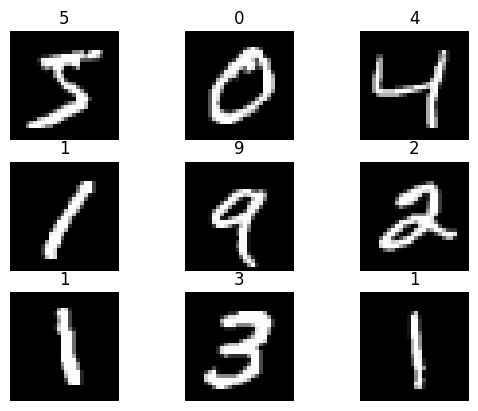

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist


#Chargemenent des données de MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

#Affichage des données
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap=plt.get_cmap('gray'))
    plt.title(train_labels[i])
    plt.axis('off')
plt.show()
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)

### 1. Prétraitement pour le réseau neuronal entièrement connecté

In [2]:
from tensorflow.keras.utils import to_categorical

# 1. Aplatir les images (28x28 -> 784)
x_train_dense = train_images.reshape((60000, 784))
x_test_dense = test_images.reshape((10000, 784))

# 2. Normalisation des pixels (0-255 -> 0-1)
x_train_dense = x_train_dense.astype('float32') / 255
x_test_dense = x_test_dense.astype('float32') / 255

# 3. Encodage One-hot des étiquettes
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

print("Forme des données d'entraînement (dense):", x_train_dense.shape)
print("Forme des étiquettes (one-hot):", y_train.shape)

Forme des données d'entraînement (dense): (60000, 784)
Forme des étiquettes (one-hot): (60000, 10)


### 2. Construction et entraînement du réseau neuronal entièrement connecté

In [3]:
from tensorflow.keras import models, layers

# Création du modèle séquentiel
model_dense = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes pour les chiffres 0-9
])

# Compilation du modèle
model_dense.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Entraînement
history_dense = model_dense.fit(x_train_dense, y_train,
                                epochs=5,
                                batch_size=128,
                                validation_split=0.2)

# Évaluation
test_loss, test_acc = model_dense.evaluate(x_test_dense, y_test)
print(f'Précision sur le test (Dense): {test_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9269 - loss: 0.2519 - val_accuracy: 0.9661 - val_loss: 0.1158
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9724 - loss: 0.0913 - val_accuracy: 0.9691 - val_loss: 0.1037
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9828 - loss: 0.0567 - val_accuracy: 0.9747 - val_loss: 0.0828
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.9753 - val_loss: 0.0875
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accuracy: 0.9787 - val_loss: 0.0783
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9789 - loss: 0.0725
Précision sur le test (Dense): 0.9789


### 3. Prétraitement et entraînement du Réseau Neuronal Convolutif (CNN)

In [4]:
# 1. Redimensionnement pour Conv2D (Ajout d'une dimension pour le canal gris)
x_train_cnn = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test_cnn = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Création du modèle CNN
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Entraînement
history_cnn = model_cnn.fit(x_train_cnn, y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.2)

# Évaluation
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test)
print(f'Précision sur le test (CNN): {test_acc_cnn:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9244 - loss: 0.2598 - val_accuracy: 0.9751 - val_loss: 0.0877
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9790 - loss: 0.0686 - val_accuracy: 0.9782 - val_loss: 0.0721
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0499 - val_accuracy: 0.9842 - val_loss: 0.0546
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9881 - loss: 0.0382 - val_accuracy: 0.9852 - val_loss: 0.0499
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9903 - loss: 0.0303 - val_accuracy: 0.9849 - val_loss: 0.0530
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0407
Précision sur le test (CNN): 0.9866


### 4. Comparaison des performances

Après avoir entraîné les deux modèles, nous pouvons observer les points suivants :

*   **Précision (Accuracy) :**
    *   Le **modèle entièrement connecté (Dense)** a atteint une précision d'environ **97.89%** sur l'ensemble de test.
    *   Le **modèle convolutif (CNN)** a atteint une précision supérieure d'environ **98.66%**.

*   **Analyse de la différence :**
    *   Le modèle CNN est plus performant car il est conçu pour traiter les données spatiales (images). Grâce aux couches de convolution, il est capable de détecter des motifs locaux (bords, formes) indépendamment de leur position dans l'image.
    *   Le réseau dense, en aplatissant l'image en un vecteur de 784 pixels, perd l'information de voisinage spatial entre les pixels, ce qui le rend moins efficace pour la vision par ordinateur, même s'il reste très performant sur un jeu de données simple comme MNIST.